In [105]:
import numpy as np

n_samples = 100
mu1, sigma1 = -5, 1.2
mu2, sigma2 = 5, 1.8
mu3, sigma3 = 0, 1.6

x1 = np.random.normal(loc = mu1, scale = np.sqrt(sigma1), size = n_samples)
x2 = np.random.normal(loc = mu2, scale = np.sqrt(sigma2), size = n_samples)
x3 = np.random.normal(loc = mu3, scale = np.sqrt(sigma3), size = n_samples)
X = np.concatenate((x1,x2,x3))


In [106]:
from scipy.stats import norm
import matplotlib.pyplot as plt
def plot_pdf(mu,sigma,label=None,alpha=0.5,linestyle='k--',density=True):
    X = norm.rvs(mu, sigma, size=1000)

    plt.hist(X, bins=50, density=density, alpha=alpha,label=label)

    # Plot the PDF
    x = np.linspace(X.min(), X.max(), 1000)
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, linestyle)

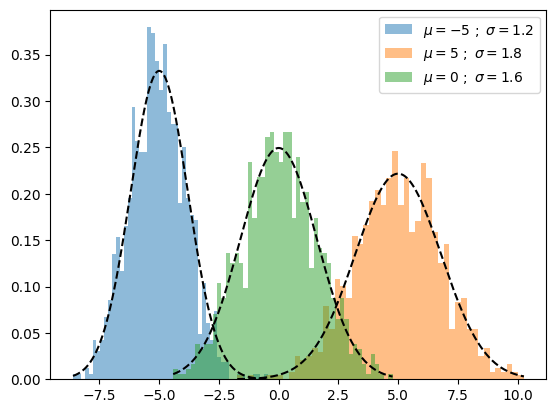

In [107]:
plot_pdf(mu1,sigma1,label=r"$\mu={} \ ; \ \sigma={}$".format(mu1,sigma1))
plot_pdf(mu2,sigma2,label=r"$\mu={} \ ; \ \sigma={}$".format(mu2,sigma2))
plot_pdf(mu3,sigma3,label=r"$\mu={} \ ; \ \sigma={}$".format(mu3,sigma3))
plt.legend()
plt.show()

In [108]:
def random_init(n_compenents):
    pi = np.ones((n_compenents)) / n_compenents
    means = np.random.choice(X, n_compenents)
    variances = np.random.random_sample(size=n_compenents)
    plot_pdf(means[0],variances[0],'Random Init 01')
    plot_pdf(means[1],variances[1],'Random Init 02')
    plot_pdf(means[2],variances[2],'Random Init 03')

    plt.legend()
    plt.show()
    print("pi: ",len(pi))
    print("means: ",len(means))
    print("variances: ",len(variances))
    return means,variances,pi

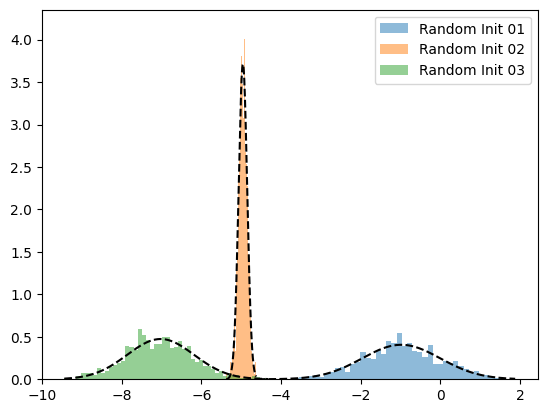

pi:  3
means:  3
variances:  3


(array([-0.98114611, -4.95837745, -7.02562122]),
 array([0.98197353, 0.10749206, 0.84141261]),
 array([0.33333333, 0.33333333, 0.33333333]))

In [109]:
random_init(3)

In [110]:
def step_expectation(X,n_components,means,variances):
    """E Step

    Parameters
    ----------
    X : array-like, shape (n_samples,)
        The data.
    n_components : int
        The number of clusters
    means : array-like, shape (n_components,)
        The means of each mixture component.
    variances : array-like, shape (n_components,)
        The variances of each mixture component.

    Returns
    -------
    weights : array-like, shape (n_components,n_samples)
    """
    weights = np.zeros((n_components,len(X)))
    for j in range(n_components):
        weights[j,:] = norm(loc=means[j],scale=np.sqrt(variances[j])).pdf(X)
    return weights

In [111]:
def complete_step_expectation(X, n_components, means, variances, priors):
    """
    完整的 E Step 逻辑

    Parameters
    ----------
    priors : array-like, shape (n_components,)
        每个高斯分量的先验权重 (pi_k)，总和为 1。
    """
    n_samples = len(X)
    # 1. 计算分子：Likelihood * Prior
    # 形状为 (n_components, n_samples)
    weighted_likelihoods = np.zeros((n_components, n_samples))

    for j in range(n_components):
        # 计算 P(x|j)
        likelihood = norm(loc=means[j], scale=np.sqrt(variances[j])).pdf(X)
        # 乘以先验权重 pi_j
        weighted_likelihoods[j, :] = likelihood * priors[j]

    # 2. 计算分母：全概率 Sum(pi_k * P(x|k))
    # 对每一列（每个样本）求和
    total_likelihood = np.sum(weighted_likelihoods, axis=0)

    # 3. 归一化：得到后验概率 (Responsibility)
    # 防止除以 0，添加一个极小值 eps
    responsibilities = weighted_likelihoods / (total_likelihood + 1e-10)

    return responsibilities


In [112]:
def step_maximization(X,weights,means,variances,n_compenents,pi):
    """M Step

    Parameters
    ----------
    X : array-like, shape (n_samples,)
        The data.
    weights : array-like, shape (n_components,n_samples)
        initilized weights array
    means : array-like, shape (n_components,)
        The means of each mixture component.
    variances : array-like, shape (n_components,)
        The variances of each mixture component.
    n_components : int
        The number of clusters
    pi: array-like (n_components,)
        mixture component weights

    Returns
    -------
    means : array-like, shape (n_components,)
        The means of each mixture component.
    variances : array-like, shape (n_components,)
        The variances of each mixture component.
    """
    r = []
    for j in range(n_compenents):

        r.append((weights[j] * pi[j]) / (np.sum([weights[i] * pi[i] for i in range(n_compenents)], axis=0)))

        #5th equation above
        means[j] = np.sum(r[j] * X) / (np.sum(r[j]))

        #6th equation above
        variances[j] = np.sum(r[j] * np.square(X - means[j])) / (np.sum(r[j]))

        #4th equation above
        pi[j] = np.mean(r[j])

    return variances,means,pi

In [113]:
def train_gmm(data,n_compenents=3,n_steps=50, plot_intermediate_steps_flag=True):
    """ Training step of the GMM model

    Parameters
    ----------
    data : array-like, shape (n_samples,)
        The data.
    n_components : int
        The number of clusters
    n_steps: int
        number of iterations to run
    """

    #intilize model parameters at the start
    means,variances,pi = random_init(n_compenents)

    for step in range(n_steps):
        #perform E step
        weights = complete_step_expectation(data,n_compenents,means,variances)
        #perform M step
        variances,means,pi = step_maximization(X, weights, means, variances, n_compenents, pi)

    plot_pdf(means,variances)

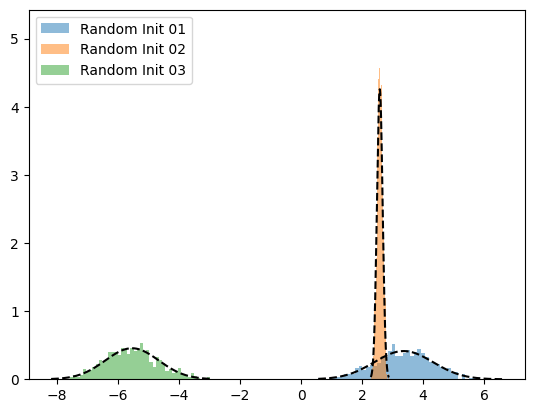

pi:  3
means:  3
variances:  3


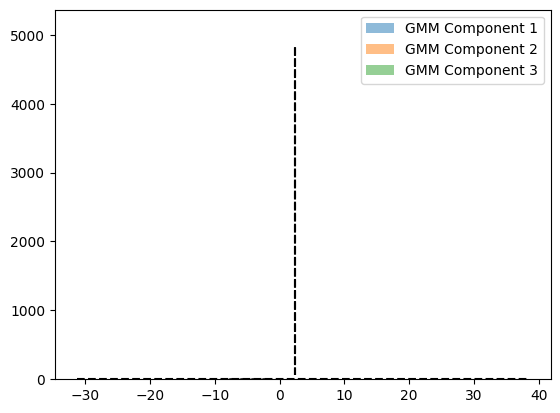

In [114]:
def train_gmm(data,n_compenents=3,n_steps=500, plot_intermediate_steps_flag=True):
    """ Training step of the GMM model

    Parameters
    ----------
    data : array-like, shape (n_samples,)
        The data.
    n_components : int
        The number of clusters
    n_steps: int
        number of iterations to run
    """

    #intilize model parameters at the start
    means,variances,pi = random_init(n_compenents)

    for step in range(n_steps):
        #perform E step
        weights = step_expectation(data,n_compenents,means,variances)
        #perform M step
        variances,means,pi = step_maximization(X, weights, means, variances, n_compenents, pi)

    # Fix: Iterate and plot each component individually
    if plot_intermediate_steps_flag:
        for i in range(n_compenents):
            plot_pdf(means[i], variances[i], label=f'GMM Component {i+1}')
        plt.legend()
        plt.show()
train_gmm(X)

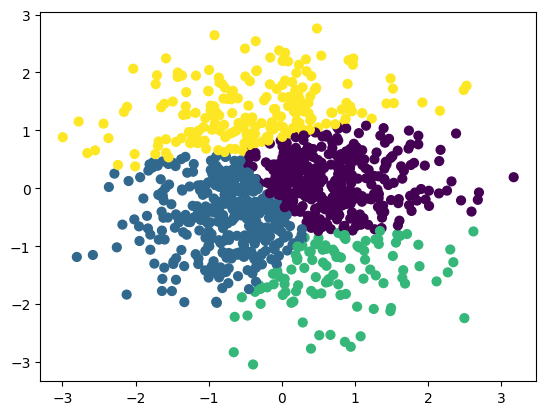

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 生成随机数据
np.random.seed(0)
n_samples = 1000
X = np.random.randn(n_samples, 2)

# 创建GMM模型对象并拟合数据
n_clusters = 4
gmm = GaussianMixture(n_components=n_clusters).fit(X)

# 预测每个样本所属的聚类
labels = gmm.predict(X)

# 可视化聚类结果
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis')
plt.show()

In [116]:
y = np.random.randn(100, 2)
#y1 = np.random.randn(10)
#X[:3], y, y1

In [117]:
labely = gmm.predict(y)
print(labely)

[0 2 0 0 0 3 3 3 1 3 0 0 3 0 3 0 1 1 0 3 3 1 3 0 1 0 0 2 1 3 3 0 0 0 0 0 0
 1 2 3 2 0 0 2 2 3 0 2 3 0 1 3 2 1 3 1 0 1 1 0 0 1 2 1 0 1 0 1 1 3 2 1 3 2
 1 1 1 3 1 1 3 3 2 0 2 3 1 1 3 1 1 3 2 3 3 1 1 0 0 2]


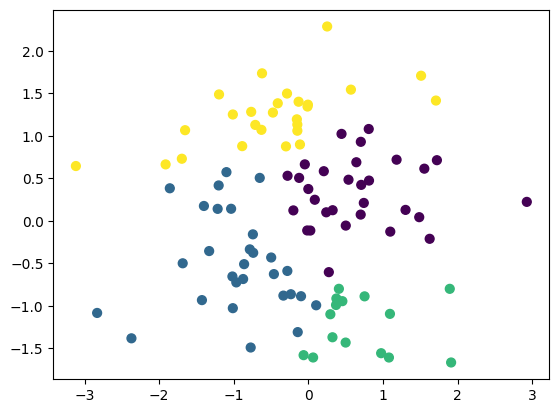

In [118]:
plt.scatter(y[:, 0], y[:, 1], s=40,c=labely, cmap='viridis')
plt.show()

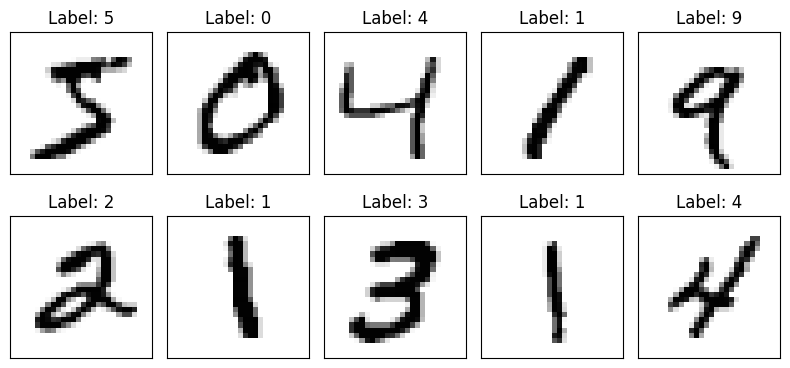

In [119]:
import numpy as np
from sklearn.mixture import GaussianMixture
from keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 加载MNIST数据集
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images_part = train_images[:2000]
train_labels_part = train_labels[:2000]

# 显示前10张图片
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(8, 4))
for ax, image, label in zip(axes.ravel(), train_images_part[:10], train_labels_part[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Label: {}'.format(label))
plt.tight_layout()
plt.show()

In [120]:
train_images_flatten = np.resize(train_images_part,
                                 (train_images_part.shape[0], train_images_part.shape[1] * train_images_part.shape[2]))


In [121]:
train_images_part.shape, train_images_part.shape[0], train_images_part.shape[1]

((2000, 28, 28), 2000, 28)

In [122]:
train_images_flatten.shape

(2000, 784)

In [123]:
pca = PCA(0.85, whiten=True)
data = pca.fit_transform(train_images_flatten)
data_rec_flatten = pca.inverse_transform(data)


In [124]:
data_rec_flatten.shape

(2000, 784)

In [125]:

data_rec = np.resize(data_rec_flatten,
                     (train_images_part.shape[0], train_images_part.shape[1], train_images_part.shape[2]))

In [131]:
data_rec = np.maximum(data_rec, 0)

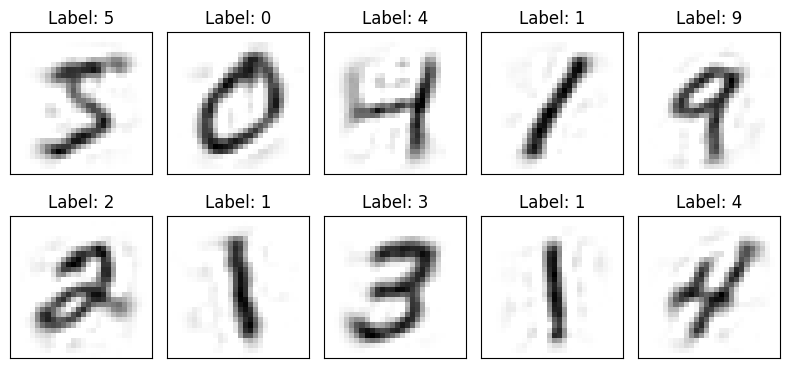

In [132]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(8, 4))
for ax, image, label in zip(axes.ravel(), data_rec[:10], train_labels_part[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Label: {}'.format(label))

plt.tight_layout()
plt.show()


In [136]:
raw_reconstruction = pca.inverse_transform(data)

print(f"Original pixels min: {train_images_part.min()}")
print(f"Original pixels max: {train_images_part.max()}")
print("---")
print(f"Reconstructed pixels min (raw): {raw_reconstruction.min()}")
print(f"Reconstructed pixels max (raw): {raw_reconstruction.max()}")

# Count how many pixels are negative
neg_count = np.sum(raw_reconstruction < 0)
total_pixels = raw_reconstruction.size
print(f"\nNumber of negative pixels: {neg_count} out of {total_pixels} ({neg_count/total_pixels:.2%})")

# This is why we use np.maximum(data_rec, 0)
data_rec_clipped = np.maximum(raw_reconstruction, 0)
print(f"Clipped pixels min: {data_rec_clipped.min()}")


Original pixels min: 0
Original pixels max: 255
---
Reconstructed pixels min (raw): -121.7478611174049
Reconstructed pixels max (raw): 352.2105438759253

Number of negative pixels: 534125 out of 1568000 (34.06%)
Clipped pixels min: 0.0


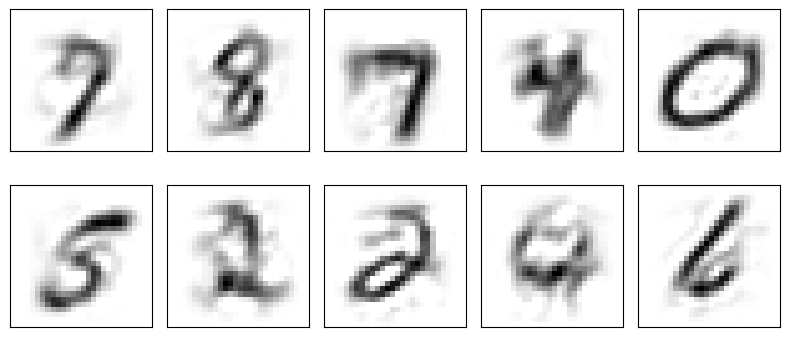

In [147]:
gmm = GaussianMixture(110, covariance_type='full',random_state=42)
gmm.fit(data)
data_new = gmm.sample(10)
"""
the variable data_new is a tuple. data_new[0] contains the
coordinates of the 10 new points in the reduced PCA space,
 and data_new[1] contains the integer labels of which Gaussian component generated each point.
"""
digits_new = pca.inverse_transform(data_new[0])
digits_new = np.reshape(digits_new, (
    digits_new.shape[0],
    train_images_part.shape[1],
    train_images_part.shape[2]
))
digits_new = np.maximum(digits_new, 0)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(8, 4))
for ax, image in zip(axes.ravel(), digits_new[:10]):
  ax.imshow(image, cmap=plt.cm.gray_r)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

In [145]:
data_new[1]

array([  1,  11,  33,  34,  50,  52,  69,  88, 104, 107])

In [148]:
axes

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)